**PJM Power Consumption Forecasting using Time Series Analysis.**

**Analyzing historical electricity consumption patterns and forecasting future power demand.**

In [1]:
# Import required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load and read Dataset
df=pd.read_excel("/content/PJMW_MW_Hourly.xlsx")

In [3]:
df

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930
...,...,...
143201,2018-01-01 20:00:00,8401
143202,2018-01-01 21:00:00,8373
143203,2018-01-01 22:00:00,8238
143204,2018-01-01 23:00:00,7958


# **EDA**

In [4]:
# Check No. of rows and no. of columns in dataset
# 143206 rows and 2 columns
df.shape

(143206, 2)

In [5]:
# Check for the missing Values
# No missing value is found
df.isna().sum()

,0
Datetime,0
PJMW_MW,0


In [6]:
# Check duplicates
# No Duplicates found
df.duplicated().sum()

np.int64(0)

In [7]:
# Quick info of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [8]:
# Statistical summary of df
df.describe()

,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


**Overall the data is in a structured format. columns datatype is correct, no duplicates, no null values, no missing values**

# **Feature Engineering**

In [9]:
# Extract year from datetime to analyze & forecast yearly power consumption
df['Year'] = df['Datetime'].dt.year
df['Year']

,Year
0,2002
1,2002
2,2002
3,2002
4,2002
...,...
143201,2018
143202,2018
143203,2018
143204,2018


In [10]:
# Extract Month from datetime to analyze & forecast monthly power consumption
df['Month'] = df['Datetime'].dt.month
df['Month']

,Month
0,12
1,12
2,12
3,12
4,12
...,...
143201,1
143202,1
143203,1
143204,1


In [11]:
# Extract day from datetime to analyze & forecast daily power consumption
df['Day'] = df['Datetime'].dt.day
df['Day']

,Day
0,31
1,31
2,31
3,31
4,31
...,...
143201,1
143202,1
143203,1
143204,1


In [12]:
# Extract hour from datetime to analyze & forecast hourly power consumption
df['Hour'] = df['Datetime'].dt.hour
df['Hour']

,Hour
0,1
1,2
2,3
3,4
4,5
...,...
143201,20
143202,21
143203,22
143204,23


In [13]:
# Extract day of weeks from datetime to analyze & forecast weekly power consumption
df['DayOfWeek'] = df['Datetime'].dt.dayofweek
df['DayOfWeek']

,DayOfWeek
0,1
1,1
2,1
3,1
4,1
...,...
143201,0
143202,0
143203,0
143204,0


In [14]:
# Extract Quarter from datetime to analyze & forecast quarterly power consumption
df['Quarter'] = df['Datetime'].dt.quarter
df['Quarter']

,Quarter
0,4
1,4
2,4
3,4
4,4
...,...
143201,1
143202,1
143203,1
143204,1


In [15]:
# extract week number
df['WeekOfYear'] = df['Datetime'].dt.isocalendar().week
df['WeekOfYear']

,WeekOfYear
0,1
1,1
2,1
3,1
4,1
...,...
143201,1
143202,1
143203,1
143204,1


In [16]:
# Unique years with its count (2002-2018)
df.value_counts(df['Year'])

,count
Year,
2016,8784
2012,8782
2004,8782
2008,8782
2014,8760
2017,8760
2015,8760
2003,8758
2005,8758


In [17]:
# Unique months with its count (Jan-Dec)
df.value_counts(df['Month'])

,count
Month,
7,12648
5,12648
6,12240
4,12234
8,11953
1,11904
12,11903
10,11899
3,11892


In [18]:
# Unique days with its count (1-31)
df.value_counts('Day')

,count
Day,
1,4727
2,4727
5,4705
15,4704
28,4704
25,4704
24,4704
23,4704
22,4704


In [19]:
# Unique Hours with its count (0-23)
df.value_counts(df['Hour'])

,count
Hour,
1,5968
6,5968
5,5968
4,5968
7,5968
10,5968
9,5968
8,5968
16,5968


In [20]:
# Unique days of week with its count (0-6, sun-sat)
df.value_counts(df['DayOfWeek'])

,count
DayOfWeek,
1,20472
2,20472
3,20472
0,20471
4,20448
5,20448
6,20423


In [21]:
# Unique Quarters with its count (1-4)
df.value_counts(df['Quarter'])

,count
Quarter,
2,37122
3,36121
4,35319
1,34644


In [22]:
# Unique no. of weeks in year with its count (1-53)
df.value_counts(df['WeekOfYear'])

,count
WeekOfYear,
16,2856
20,2856
19,2856
21,2856
18,2856
15,2856
17,2856
27,2856
26,2856


In [23]:
df['IsWeekend'] = df['DayOfWeek'].isin([5,6]).astype(int)
df['IsWeekend']

,IsWeekend
0,0
1,0
2,0
3,0
4,0
...,...
143201,0
143202,0
143203,0
143204,0


In [24]:
# weekend with its count (0,1)
df.value_counts(df['IsWeekend'])

,count
IsWeekend,
0,102335
1,40871


In [25]:
df

,Datetime,PJMW_MW,Year,Month,Day,Hour,DayOfWeek,Quarter,WeekOfYear,IsWeekend
0,2002-12-31 01:00:00,5077,2002,12,31,1,1,4,1,0
1,2002-12-31 02:00:00,4939,2002,12,31,2,1,4,1,0
2,2002-12-31 03:00:00,4885,2002,12,31,3,1,4,1,0
3,2002-12-31 04:00:00,4857,2002,12,31,4,1,4,1,0
4,2002-12-31 05:00:00,4930,2002,12,31,5,1,4,1,0
...,...,...,...,...,...,...,...,...,...,...
143201,2018-01-01 20:00:00,8401,2018,1,1,20,0,1,1,0
143202,2018-01-01 21:00:00,8373,2018,1,1,21,0,1,1,0
143203,2018-01-01 22:00:00,8238,2018,1,1,22,0,1,1,0
143204,2018-01-01 23:00:00,7958,2018,1,1,23,0,1,1,0


In [26]:
# All columns datatype is correct.
df.dtypes

,0
Datetime,datetime64[ns]
PJMW_MW,int64
Year,int32
Month,int32
Day,int32
Hour,int32
DayOfWeek,int32
Quarter,int32
WeekOfYear,UInt32
IsWeekend,int64


# **Visualization**

# **1. Time Series Plot**

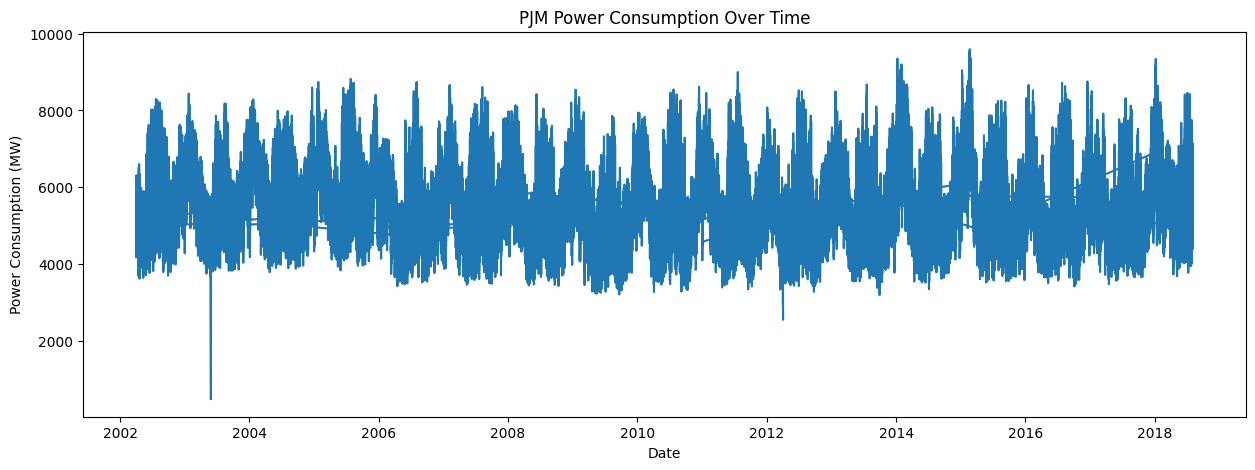

In [27]:
# This helps identify: Trend, Seasonality, Sudden spikes/drops

plt.figure(figsize=(15,5))
plt.plot(df['Datetime'], df['PJMW_MW'])
plt.title('PJM Power Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Power Consumption (MW)')
plt.show()

Clear repetitive patterns are visible.

Demand fluctuates regularly over time.

No long-term increasing or decreasing trend is observed.

Strong seasonality exists.

A few sharp spikes and drops are present, representing extreme demand periods or unusual events.

The time series exhibits strong seasonal behavior with recurring fluctuations, suggesting that electricity demand is influenced by cyclical factors such as weather conditions and human activity patterns. **bold text**

# **2. Distribution Plot**

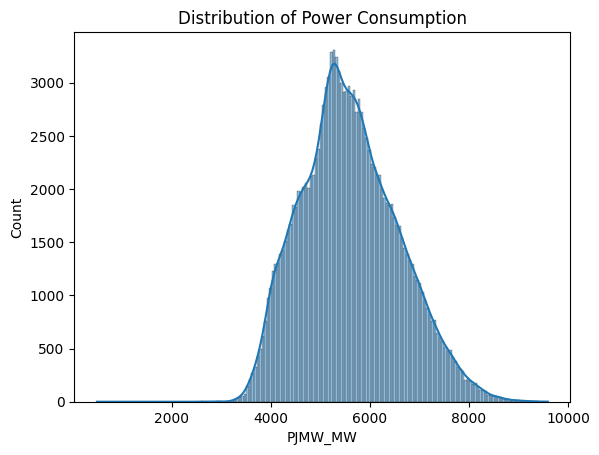

In [28]:
# Check whether the data is normally distributed or skewed.
sns.histplot(df['PJMW_MW'], kde=True)
plt.title('Distribution of Power Consumption')
plt.show()

**Power consumption is approximately bell-shaped (near normal distribution).**

**Most values lie between 4,500 MW and 7,000 MW.**

**Peak frequency occurs around 5,500–6,000 MW.**

**Very low and very high consumption values are rare.**

**The power consumption data follows an approximately normal distribution, with most observations concentrated around 5,500–6,000 MW, indicating stable energy demand over the years.**

# **3. Box Plot (Outlier Detection)**

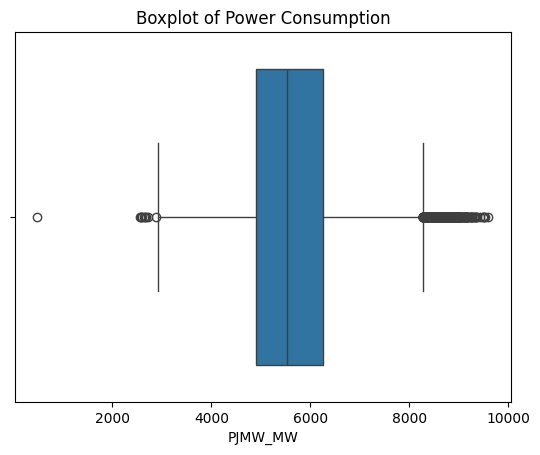

In [29]:
sns.boxplot(x=df['PJMW_MW'])
plt.title('Boxplot of Power Consumption')
plt.show()

**Several outliers exist.**

**Most values are concentrated around the median.**

**Outliers represent genuine peak-demand events rather than data errors.**

**Although several outliers are present, they likely correspond to legitimate peak-demand periods and were retained for analysis.**

# **4. Average Consumption by Month**

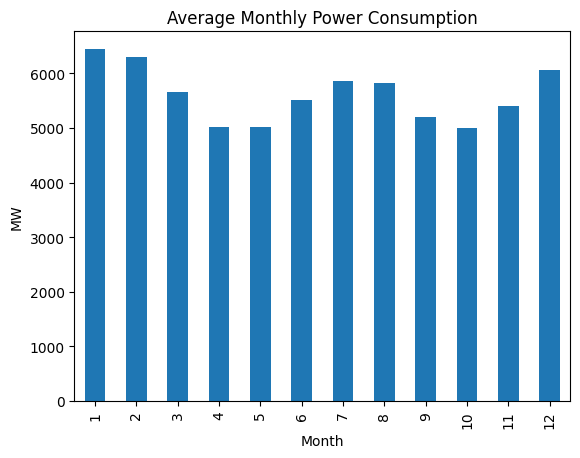

In [30]:
monthly_avg = df.groupby('Month')['PJMW_MW'].mean()

monthly_avg.plot(kind='bar')
plt.title('Average Monthly Power Consumption')
plt.ylabel('MW')
plt.show()

**Highest consumption occurs in:**

**January**

**February**

**December**

**Lower consumption observed during:**

**April**

**May**

**September**

**This likely reflects seasonal temperature changes.**

**Monthly analysis shows higher electricity demand during winter months and relatively lower demand during transitional seasons.**

# **5. Average Consumption by Day of Week**

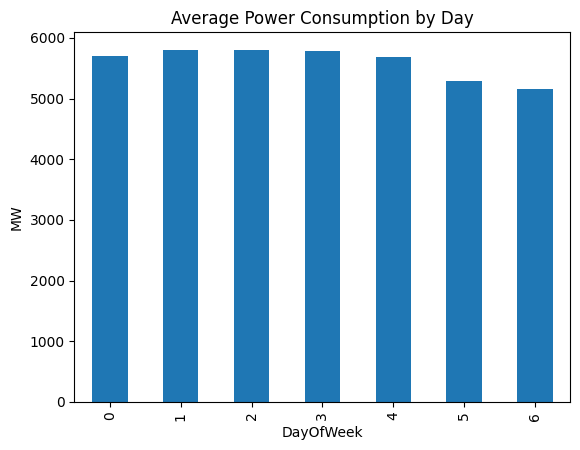

In [31]:
day_avg = df.groupby('DayOfWeek')['PJMW_MW'].mean()

day_avg.plot(kind='bar')
plt.title('Average Power Consumption by Day')
plt.ylabel('MW')
plt.show()

**Consumption is relatively consistent across weekdays.**

**Slight reduction observed during weekends.**

**Indicates industrial/commercial activities influence demand.**

**Daily consumption patterns indicate slightly lower electricity usage during weekends compared to weekdays.**

# **6. Average Consumption by Hour**

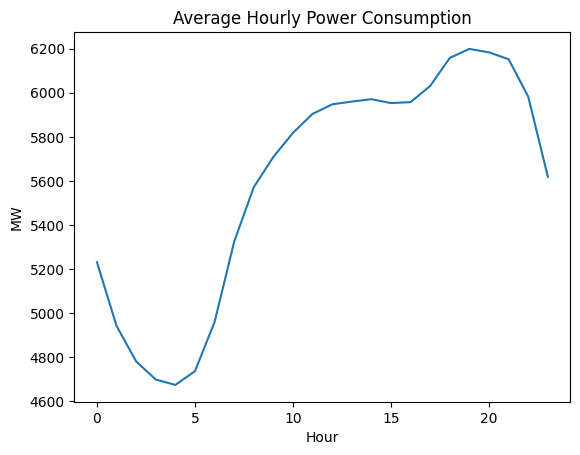

In [32]:
hour_avg = df.groupby('Hour')['PJMW_MW'].mean()

hour_avg.plot(kind='line')
plt.title('Average Hourly Power Consumption')
plt.ylabel('MW')
plt.show()

**Lowest demand occurs during late night and early morning hours.**

**Demand rises sharply after morning.**

**Peaks during afternoon/evening.**

**Falls again at night.**

**This is a classic daily electricity demand cycle.**

**Hourly consumption analysis reveals a clear daily cycle, with demand increasing during daytime hours and decreasing during late-night periods.**

# **7. Consumption by Weekday vs Weekend**

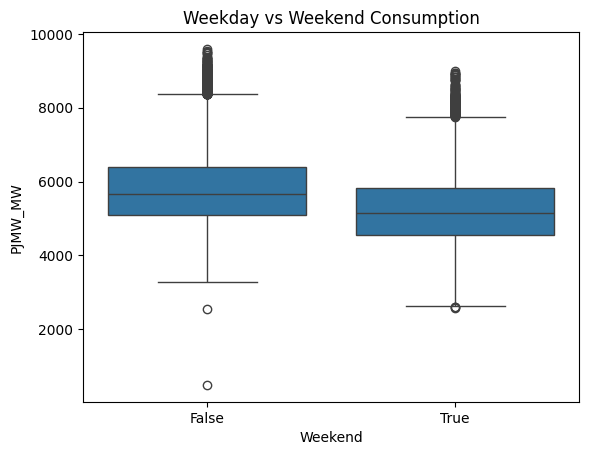

In [33]:
df['Weekend'] = df['Datetime'].dt.dayofweek >= 5

sns.boxplot(x='Weekend', y='PJMW_MW', data=df)
plt.title('Weekday vs Weekend Consumption')
plt.show()

**Weekend consumption is slightly lower.**

**Distribution on weekdays is broader.**

**More variability during working days.**

**Weekday electricity demand exhibits greater variability than weekend demand, likely due to increased industrial and commercial activities.**

# **8. Rolling Mean**

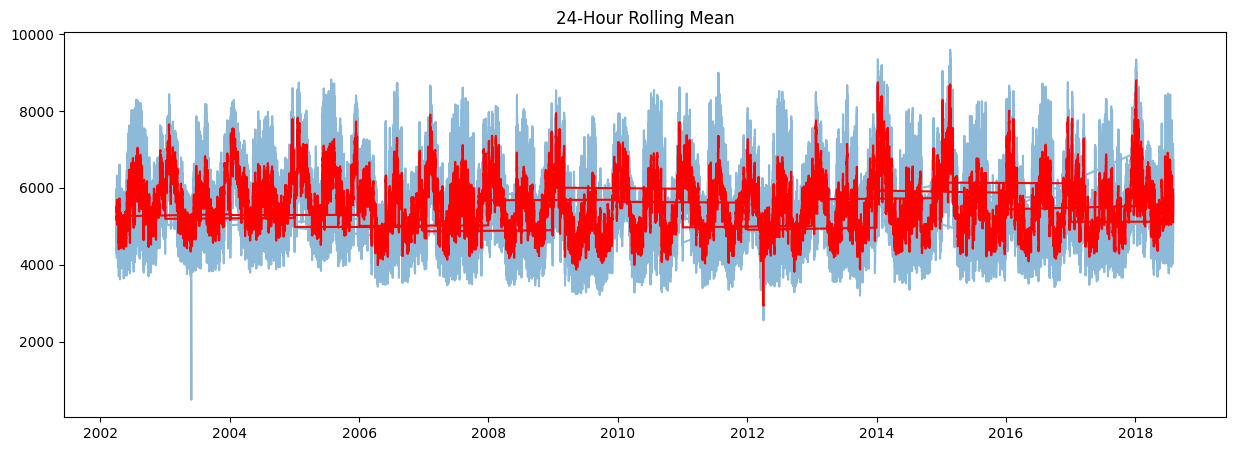

In [34]:
df.set_index('Datetime', inplace=True)

rolling_mean = df['PJMW_MW'].rolling(window=24).mean()

plt.figure(figsize=(15,5))
plt.plot(df['PJMW_MW'], alpha=0.5)
plt.plot(rolling_mean, color='red')
plt.title('24-Hour Rolling Mean')
plt.show()

**Forecasted values closely follow historical patterns.**

**Model captures recurring fluctuations effectively.**

**Indicates good predictive capability.**

**The forecasting model successfully captures the seasonal behavior of electricity consumption and produces predictions that closely align with observed demand patterns.**

# **9. Seasonal Decomposition**

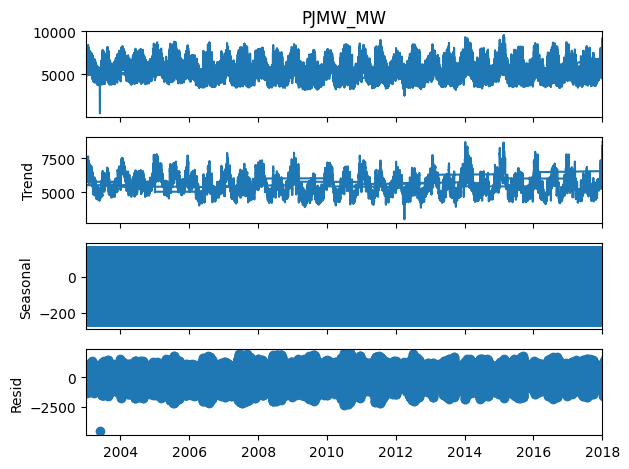

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df['PJMW_MW'],
    model='additive',
    period=24
)

decomposition.plot()
plt.show()

# This separates: Trend, Seasonality, Residuals

# **Trend**

**Trend remains fairly stable.**

**No major upward or downward movement.**

# **Seasonal Component**

**Strong repeating seasonal cycles.**

**Seasonality is one of the strongest characteristics of the dataset.**
**bold text**
# **Residuals**

**Residuals are centered around zero.**

**Most variation is explained by trend and seasonality.**

Seasonal decomposition reveals strong recurring seasonal patterns, while the residual component remains relatively small, indicating that seasonality is a dominant factor affecting electricity demand.

# **10. Year-wise Power Consumption**

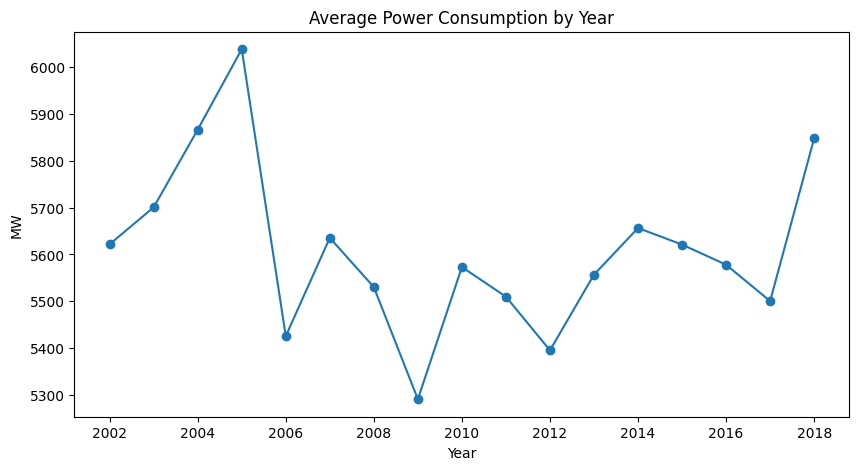

In [36]:
yearly_avg = df.groupby('Year')['PJMW_MW'].mean()

plt.figure(figsize=(10,5))
yearly_avg.plot(kind='line', marker='o')
plt.title('Average Power Consumption by Year')
plt.ylabel('MW')
plt.show()

**Average yearly demand remains relatively stable.**

**Some fluctuations exist, but no dramatic long-term growth or decline.**

**Demand appears mature and predictable.**

**Yearly average power consumption remains relatively stable, indicating consistent electricity demand throughout the observation period.**

# **11. Monthly Trend Across Years**

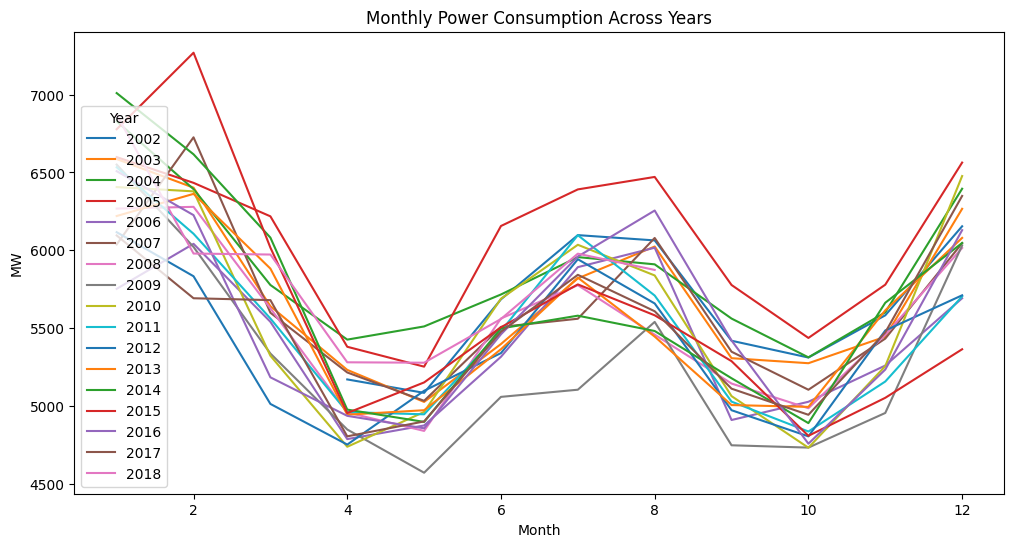

In [37]:
monthly_yearly = df.groupby(['Year','Month'])['PJMW_MW'].mean().unstack()

monthly_yearly.T.plot(figsize=(12,6))
plt.title('Monthly Power Consumption Across Years')
plt.ylabel('MW')
plt.show()

**Similar monthly patterns repeat every year.**

**Consumption tends to be:**

**Higher in winter months.**

**Lower during spring and autumn.**

**Indicates yearly seasonality.**

**Monthly energy consumption follows a consistent seasonal pattern across years, confirming the presence of annual seasonality in electricity demand.**

In [38]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['PJMW_MW'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -19.53097878897816
p-value: 0.0


p-value < 0.05.         
     
The PJM power consumption series is stationary.               

The Augmented Dickey-Fuller (ADF) test was performed to check the stationarity of the time series data. The obtained ADF statistic was -19.53 with a p-value of 0.0. Since the p-value is less than 0.05, the null hypothesis of non-stationarity is rejected. Therefore, the power consumption time series is stationary and suitable for time-series forecasting models.

In [39]:
df

,PJMW_MW,Year,Month,Day,Hour,DayOfWeek,Quarter,WeekOfYear,IsWeekend,Weekend
Datetime,,,,,,,,,,
2002-12-31 01:00:00,5077,2002,12,31,1,1,4,1,0,False
2002-12-31 02:00:00,4939,2002,12,31,2,1,4,1,0,False
2002-12-31 03:00:00,4885,2002,12,31,3,1,4,1,0,False
2002-12-31 04:00:00,4857,2002,12,31,4,1,4,1,0,False
2002-12-31 05:00:00,4930,2002,12,31,5,1,4,1,0,False
...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,8401,2018,1,1,20,0,1,1,0,False
2018-01-01 21:00:00,8373,2018,1,1,21,0,1,1,0,False
2018-01-01 22:00:00,8238,2018,1,1,22,0,1,1,0,False


In [40]:
# Sort the data
df = df.sort_index()

In [41]:
# Top 50 entries
df.head(50)

,PJMW_MW,Year,Month,Day,Hour,DayOfWeek,Quarter,WeekOfYear,IsWeekend,Weekend
Datetime,,,,,,,,,,
2002-04-01 01:00:00,4374,2002,4,1,1,0,2,14,0,False
2002-04-01 02:00:00,4306,2002,4,1,2,0,2,14,0,False
2002-04-01 03:00:00,4322,2002,4,1,3,0,2,14,0,False
2002-04-01 04:00:00,4359,2002,4,1,4,0,2,14,0,False
2002-04-01 05:00:00,4436,2002,4,1,5,0,2,14,0,False
2002-04-01 06:00:00,4723,2002,4,1,6,0,2,14,0,False
2002-04-01 07:00:00,5180,2002,4,1,7,0,2,14,0,False
2002-04-01 08:00:00,5482,2002,4,1,8,0,2,14,0,False
2002-04-01 09:00:00,5616,2002,4,1,9,0,2,14,0,False


In [42]:
# Check duplicates
# Even after sorting, duplicates can still exist.
# 4 duplicates found
df.index.duplicated().sum()

np.int64(4)

In [43]:
# Group all rows having same timestamp
# Combine them into one group
# Take the average (mean) of values
df = df.groupby(df.index).mean()

In [44]:
# Ensure Proper Frequency (Hourly Data)
df = df.asfreq('h')

In [45]:
# Check missing values
# Missing values found
df.isnull().sum()

,0
PJMW_MW,30
Year,30
Month,30
Day,30
Hour,30
DayOfWeek,30
Quarter,30
WeekOfYear,30
IsWeekend,30
Weekend,30


In [46]:
# Fill missing values
df = df.ffill()

In [47]:
# Confirm Stationarity
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['PJMW_MW'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -19.934312486472066
p-value: 0.0


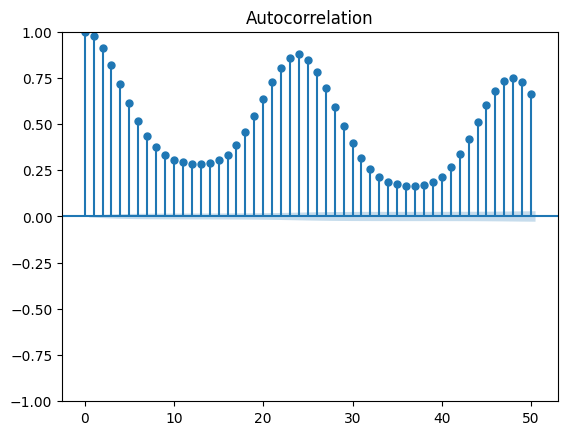

In [48]:
# ACF (Autocorrelation Function)
# This tells ----> How much current value depends on past values
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(df['PJMW_MW'], lags=50)
plt.show()

**Very strong autocorrelation.**

**Cyclical peaks occur at regular intervals.**

**Strong seasonal dependence exists.**

**Current consumption is highly related to past consumption.**

**The ACF plot indicates strong temporal dependence and recurring seasonal cycles, making the dataset highly suitable for time-series forecasting models.**

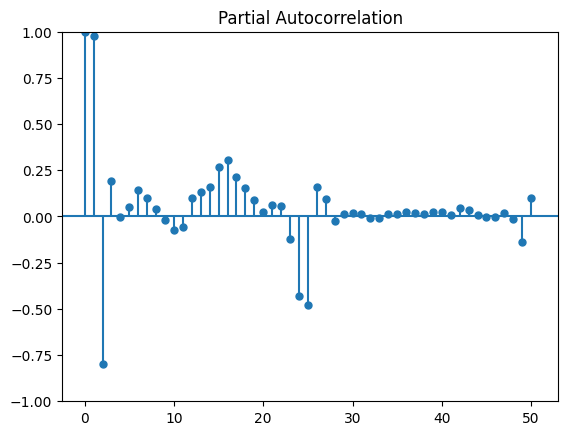

In [49]:
# PACF (Partial Autocorrelation Function)
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['PJMW_MW'], lags=50)
plt.show()

**Significant spikes appear in the first few lags.**

**Influence decreases gradually afterward.**

**Indicates strong short-term dependency.**

**The PACF plot shows significant influence from recent observations, suggesting that autoregressive components should be included in the forecasting model.**